# Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # data visualisation library
import seaborn as sns  # data visualization libraray

In [2]:
data=pd.read_csv("Advertising.csv")
data.head(3)

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


In [3]:
data.shape

(200, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


a:\Python\venv\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


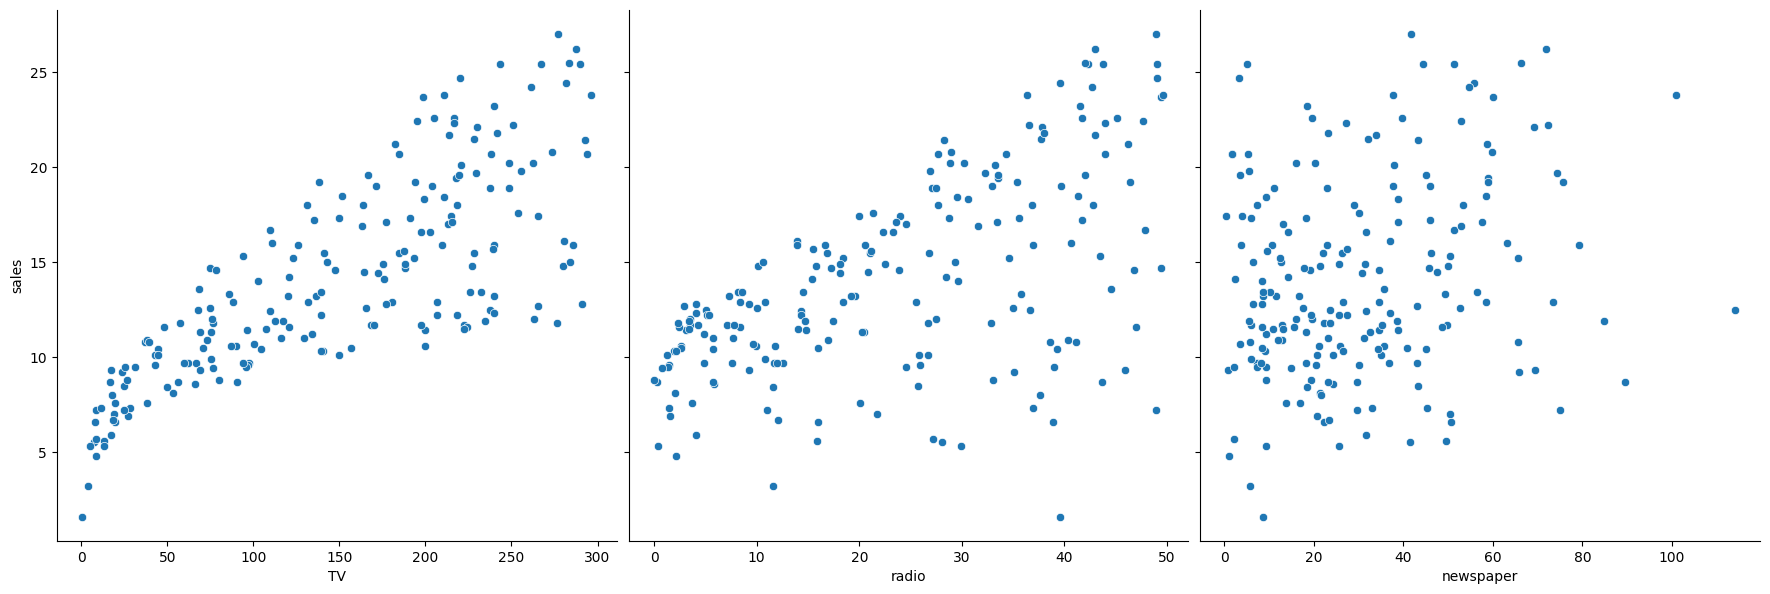

In [5]:
# Plot the data

#sns.pairplot(data)# this will give alll comparison
sns.pairplot(data,x_vars=["TV","radio","newspaper"],y_vars=["sales"],size=6)

In [6]:
# select the feature variable aswell as target variable
# simple Regression discuss 1 feature

X=data.loc[:,["TV"]]  # TV feature
y=data.loc[:,["sales"]]  # sale target

# Split the data as train and test¶


In [7]:
# Scikit learn - conatins all machine laerning library
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160, 1)
(40, 1)


# Training the Simple linear Regression model on Training set


In [9]:
from sklearn.linear_model import LinearRegression # build the Linear Regression model
lr=LinearRegression()

In [10]:
lr.fit(X_train,y_train) # fit the model

LinearRegression()

In [11]:
print("intercept Value",lr.intercept_)

print("The model slope",lr.coef_)

intercept Value [6.83626781]
The model slope [[0.0486949]]


In [12]:
ypredtrain=lr.predict(X_train)

In [13]:
ypredtrain


array([[11.58402075],
       [10.49325495],
       [11.20420051],
       [17.10115314],
       [10.05500083],
       [20.9431809 ],
       [11.23828695],
       [ 9.5729213 ],
       [17.95331392],
       [18.5133053 ],
       [10.27412789],
       [ 9.73848397],
       [15.0364893 ],
       [18.67886796],
       [14.95857745],
       [ 7.09922028],
       [ 9.00319095],
       [18.93208145],
       [15.98603989],
       [10.09395675],
       [14.7881453 ],
       [10.51273291],
       [16.90637353],
       [13.55129479],
       [18.52791377],
       [ 8.93501808],
       [11.72523597],
       [17.47610388],
       [ 7.74686248],
       [10.64420914],
       [13.62920663],
       [ 9.18823157],
       [18.39643753],
       [11.49636993],
       [10.47377699],
       [17.83157667],
       [13.7947693 ],
       [20.99187581],
       [ 7.78094891],
       [17.74392585],
       [19.62841855],
       [11.52071738],
       [10.55655832],
       [ 9.27101291],
       [17.56375471],
       [16

In [14]:
ypredtrain=ypredtrain.flatten()


In [15]:
y_train=np.array(y_train)


In [16]:
y_train=y_train.flatten()


In [17]:
pd.DataFrame({"Actual value":y_train,"Predicted value":ypredtrain})


,Actual value,Predicted value
0,9.7,11.584021
1,12.6,10.493255
2,10.6,11.204201
3,23.8,17.101153
4,8.6,10.055001
...,...,...
155,18.0,13.220169
156,8.8,8.141291
157,7.6,7.790688
158,7.6,8.696413


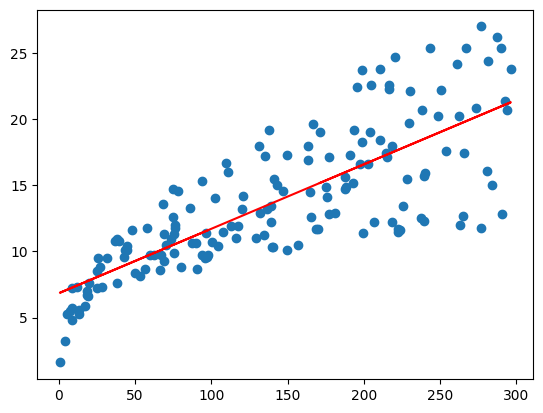

In [18]:
plt.scatter(X_train,y_train)
plt.plot(X_train,ypredtrain,color="red")
plt.show()

In [19]:
from sklearn.metrics import mean_squared_error,r2_score
print("The RMS value for Train data")
print("---------------")
print(np.sqrt(mean_squared_error(y_train,ypredtrain)))

The RMS value for Train data
---------------
3.2241455098873772


In [20]:
ypredtra=r2_score(y_train,ypredtrain)
ypredtra

0.6235446537157594

# Checking for Test Data


In [21]:
ypredtest=lr.predict(X_test)


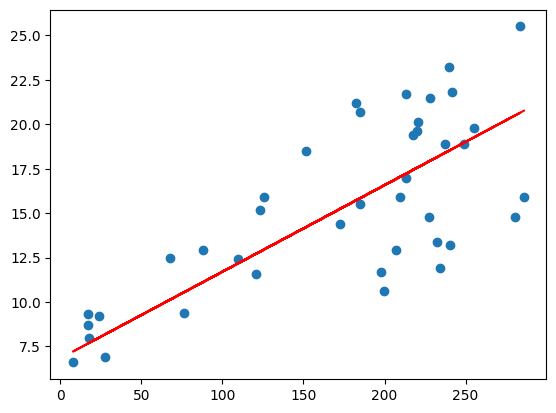

In [22]:
plt.scatter(X_test,y_test)
plt.plot(X_test,ypredtest,color="red")
plt.show()

In [23]:
print("The RMS value for Test data")
print("---------------")
print(np.sqrt(mean_squared_error(y_test,ypredtest)))

The RMS value for Test data
---------------
3.321955243801897


In [24]:
ypredtes=r2_score(y_test,ypredtest)
ypredtes

0.5198618746562338

# Multiple linear regression


In [25]:
xnew=data.drop([("sales")],axis=1)
ynew=data["sales"]
               

In [26]:
X_train,X_test,y_train,y_test=train_test_split(xnew,ynew,test_size=0.2,random_state=10)


In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [28]:
mlr=LinearRegression()
mlr.fit(X_train,y_train)

LinearRegression()

In [29]:
print("intercept Value",mlr.intercept_)

print("The model slope",mlr.coef_)

intercept Value 3.254097114418883
The model slope [ 0.0437726   0.19343299 -0.00222879]


In [30]:
coeff_df=pd.DataFrame(mlr.coef_,X_test.columns,columns=["coefficient"])
coeff_df

,coefficient
TV,0.043773
radio,0.193433
newspaper,-0.002229


In [31]:
ypredtra_m=mlr.predict(X_train)
ypredtra_m

array([12.92028367, 12.28099653, 15.1487058 , 10.10054313, 21.99161246,
       10.76747572, 14.7661212 , 15.05785147,  8.916832  , 12.05627807,
        8.377599  , 13.87664564, 23.02502886, 17.51275854, 14.57984468,
        5.93510118, 24.74044038, 17.80201748, 10.05985156,  8.36363062,
        7.14851131, 14.59817458, 16.39674242, 13.26888438, 18.67152907,
       18.94060348, 13.98744306, 15.65288507, 12.13366533,  9.38648223,
       14.52019973, 10.22712641,  8.30724473, 13.82043061, 17.13600698,
       16.3789032 , 14.77656602, 11.26256506,  6.72008424, 17.37625531,
       11.71328264, 14.46160012,  7.73207983,  7.64554012, 16.14425695,
       15.39546845, 20.05274825, 18.13413086, 23.10728723, 16.67969734,
        9.49779947, 18.44950617, 10.40442798, 20.84183307, 18.41684259,
        9.34843592, 17.74404443, 16.45800549, 23.27907498, 18.45353356,
       15.97764425,  6.36103017,  9.70729862, 17.13000423, 15.20071512,
        8.87848374, 15.36071069, 12.39794329,  8.63463214, 21.45

In [32]:
pd.DataFrame({"Actual value":y_train,"Predicted value":ypredtra_m})


,Actual value,Predicted value
190,10.8,12.920284
7,13.2,12.280997
26,15.0,15.148706
138,9.6,10.100543
58,23.8,21.991612
...,...,...
113,15.9,16.389706
64,18.0,17.207205
15,22.4,20.916114
125,10.6,9.295852


In [33]:
print("The RMS value for Train data")
print("---------------")
print(np.sqrt(mean_squared_error(y_train,ypredtra_m)))

The RMS value for Train data
---------------
1.3633035872281898


In [34]:
r2_score(y_train,ypredtra_m)


0.9209087553499528

In [35]:
ypredtest_m=mlr.predict(X_test)
ypredtest_m

array([18.1625299 , 12.92663232, 18.0531098 , 23.64464668, 20.70438374,
       14.28227997, 14.94493548, 21.38232981, 21.17508238, 12.73110461,
       24.00312134,  7.21544071, 12.24762152, 19.24345998, 19.38241854,
       13.45643798, 19.6247089 ,  9.2531648 , 21.13268075, 20.90762408,
       15.53485445, 10.92529369, 22.82955184, 15.8122438 , 17.42515749,
        8.16218669, 11.89783444, 12.70337575, 21.74138085,  7.96215368,
       12.50099965, 20.45535282,  4.72120047,  4.72259288, 16.75292333,
       15.75804986,  6.74415499, 17.73477354,  9.01591827, 13.617599  ])

In [36]:
pd.DataFrame({"Actual value":y_test,"Predicted value":ypredtest_m})


,Actual value,Predicted value
59,18.4,18.162530
5,7.2,12.926632
20,18.0,18.053110
198,25.5,23.644647
52,22.6,20.704384
19,14.6,14.282280
162,14.9,14.944935
55,23.7,21.382330
69,22.3,21.175082
2,9.3,12.731105


In [37]:
print("The RMS value for Test data")
print("---------------")
print(np.sqrt(mean_squared_error(y_test,ypredtest_m)))

The RMS value for Test data
---------------
2.58852984462781


In [38]:
r2_score(y_test,ypredtest_m)

0.8353672324670594